# DESI + MaNGA Minimal Workflow
This notebook is intentionally compact with significant portions generated by Claude Code.

It provides one clean API (`PairExtractor`) and one demo call that does all of the following:
1. Loads one DESI sample using your `MultimodalDataset` into a one-sample `DataLoader`.
2. Visualizes the DESI image with your image function and plots the DESI spectrum.
3. Fetches and visualizes associated MaNGA maps.
4. Extracts a MaNGA spectrum at a chosen sky location, marks that location on an SDSS image, and plots the extracted spectrum.

In [1]:
import os
import sys
import math
import random
import torch

sys.path.append("..")
from io import BytesIO
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import requests
import zarr
import matplotlib.pyplot as plt
from PIL import Image
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from torch.utils.data import DataLoader

from utils.DataProcessing import MultimodalDataset
from utils.AstroImageFunctions import make_rgb
from train.FixedCLSTokenTrain import MaskedAutoencoderViT

from utils.DataProcessing import (
    generate_rest_indices,
    get_extreme_mask,
    get_kernel,
    safe_collate,
    smooth_data,
    MultimodalDataset,
    CreateMultimodalDataLoadersIter,
)


class PairExtractor:
    def __init__(
        self,
        desi_zarr_path='/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr',
        desi_parquet_path='/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet',
        drpall_cache='/pscratch/sd/p/pzehao/MyQuota/drpall-v3_1_1.fits',
        maps_cache_dir='/pscratch/sd/p/pzehao/MyQuota/manga_maps',
        cube_cache_dir='/pscratch/sd/p/pzehao/MyQuota/manga_cubes',
        map_daptype='HYB10-MILESHC-MASTARHC2',
    ):
        self.desi_zarr_path = Path(desi_zarr_path)
        self.desi_parquet_path = Path(desi_parquet_path)
        self.drpall_cache = Path(drpall_cache)
        self.maps_cache_dir = Path(maps_cache_dir)
        self.cube_cache_dir = Path(cube_cache_dir)
        self.map_daptype = map_daptype

        self.z = zarr.open(str(self.desi_zarr_path), mode='r')
        self.wave = np.asarray(self.z['WAVE'][:], dtype=np.float32)
        self._desi = None
        self._manga = None

    @staticmethod
    def _txt(x):
        if isinstance(x, (bytes, np.bytes_)):
            return x.decode('utf-8')
        return str(x)

    def desi_table(self):
        if self._desi is None:
            cols = [
                'TARGETID', 'TARGET_RA', 'TARGET_DEC', 'MEAN_FIBER_RA', 'MEAN_FIBER_DEC', 'Z'
            ]
            t = pd.read_parquet(self.desi_parquet_path, columns=cols).copy()
            t['TARGETID'] = t['TARGETID'].astype(np.int64)
            self._desi = t
        return self._desi

    def manga_table(self):
        if self._manga is None:
            from astropy.table import Table
            if not self.drpall_cache.exists():
                self.drpall_cache.parent.mkdir(parents=True, exist_ok=True)
                url = 'https://data.sdss.org/sas/dr17/manga/spectro/redux/v3_1_1/drpall-v3_1_1.fits'
                urlretrieve(url, self.drpall_cache)
            tbl = Table.read(self.drpall_cache, hdu=1)
            one_d = [c for c in tbl.colnames if len(tbl[c].shape) <= 1]
            df = tbl[one_d].to_pandas()
            df = df[['plateifu', 'objra', 'objdec']].copy()
            df['plateifu'] = df['plateifu'].map(self._txt)
            df = df.rename(columns={'objra': 'manga_ra', 'objdec': 'manga_dec'})
            self._manga = df
        return self._manga

    def get_loader(self, desi_index):
        ds = MultimodalDataset(str(self.desi_zarr_path), start=int(desi_index), end=int(desi_index)+1, augment=False, max_shift=0)
        loader = DataLoader(ds, batch_size=1, shuffle=False)
        return loader

    def match_manga(self, target_ra, target_dec):
        mt = self.manga_table()
        c1 = SkyCoord([target_ra] * u.deg, [target_dec] * u.deg)
        c2 = SkyCoord(mt['manga_ra'].to_numpy() * u.deg, mt['manga_dec'].to_numpy() * u.deg)
        idx, sep2d, _ = c1.match_to_catalog_sky(c2)
        return mt.iloc[int(idx[0])]['plateifu'], float(sep2d.arcsec[0])

    def _maps_path(self, plateifu):
        plate, ifu = plateifu.split('-')
        self.maps_cache_dir.mkdir(parents=True, exist_ok=True)
        p = self.maps_cache_dir / f'manga-{plateifu}-MAPS-{self.map_daptype}.fits.gz'
        if not p.exists():
            u = (
                f'https://data.sdss.org/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/'
                f'{self.map_daptype}/{plate}/{ifu}/manga-{plateifu}-MAPS-{self.map_daptype}.fits.gz'
            )
            urlretrieve(u, p)
        return p

    def _cube_path(self, plateifu):
        plate = plateifu.split('-')[0]
        self.cube_cache_dir.mkdir(parents=True, exist_ok=True)
        p = self.cube_cache_dir / f'manga-{plateifu}-LOGCUBE.fits.gz'
        if not p.exists():
            u = f'https://data.sdss.org/sas/dr17/manga/spectro/redux/v3_1_1/{plate}/stack/manga-{plateifu}-LOGCUBE.fits.gz'
            urlretrieve(u, p)
        return p

    @staticmethod
    def _ch(header, token):
        token = token.lower()
        for k, v in header.items():
            if isinstance(k, str) and k.startswith('C') and isinstance(v, str) and token in v.lower():
                return int(k[1:]) - 1
        raise KeyError(token)

    @staticmethod
    def _masked(h, ext, idx=None):
        d = np.asarray(h[ext].data if idx is None else h[ext].data[idx], dtype=np.float32)
        bad = np.zeros_like(d, dtype=bool)
        me = f'{ext}_MASK'
        ie = f'{ext}_IVAR'
        if me in h:
            m = np.asarray(h[me].data if idx is None else h[me].data[idx])
            bad |= (m != 0)
        if ie in h:
            iv = np.asarray(h[ie].data if idx is None else h[ie].data[idx], dtype=np.float32)
            bad |= (~np.isfinite(iv)) | (iv <= 0)
        d[bad] = np.nan
        return d

    def get_maps(self, plateifu):
        p = self._maps_path(plateifu)
        with fits.open(p) as h:
            i_ha = self._ch(h['EMLINE_GFLUX'].header, 'Ha-6564')
            i_gv = self._ch(h['EMLINE_GVEL'].header, 'Ha-6564')
            try:
                i_dn = self._ch(h['SPECINDEX'].header, 'Dn4000')
            except KeyError:
                i_dn = self._ch(h['SPECINDEX'].header, 'D4000')
            return {
                'manga_image': self._masked(h, 'SPX_MFLUX'),
                'ha_flux': self._masked(h, 'EMLINE_GFLUX', i_ha),
                'gas_velocity': self._masked(h, 'EMLINE_GVEL', i_gv),
                'stellar_velocity': self._masked(h, 'STELLAR_VEL'),
                'dn4000': self._masked(h, 'SPECINDEX', i_dn),
            }

    def get_sdss_image(self, ra, dec, width=256, height=256, scale=0.262):
        u = (
            'https://skyserver.sdss.org/dr17/SkyServerWS/ImgCutout/getjpeg'
            f'?ra={ra}&dec={dec}&scale={scale}&width={width}&height={height}'
        )
        r = requests.get(u, timeout=60)
        r.raise_for_status()
        return np.array(Image.open(BytesIO(r.content)).convert('RGB'))

    def spectrum_from_cube(self, plateifu, ra, dec):
        p = self._cube_path(plateifu)
        with fits.open(p) as h:
            cube = np.asarray(h['FLUX'].data, dtype=np.float32)
            wave = np.asarray(h['WAVE'].data, dtype=np.float32)
            w = WCS(h['FLUX'].header).celestial
            x, y = w.world_to_pixel_values(float(ra), float(dec))
            ix, iy = int(np.round(x)), int(np.round(y))
            flux = cube[:, iy, ix]
            cx, cy = w.pixel_to_world_values(ix, iy)
        dra = (ra - cx) * np.cos(np.deg2rad(dec)) * 3600.0
        ddec = (dec - cy) * 3600.0
        sep = float(np.hypot(dra, ddec))
        return {'wave': wave, 'flux': flux, 'ix': ix, 'iy': iy, 'sep_arcsec': sep}

    @staticmethod
    def sky_to_cutout_pixel(ra, dec, ra0, dec0, width, height, scale_arcsec=0.262):
        dx = (ra - ra0) * np.cos(np.deg2rad(dec0)) * 3600.0 / scale_arcsec
        dy = (dec - dec0) * 3600.0 / scale_arcsec
        x = width / 2 + dx
        y = height / 2 - dy
        return float(x), float(y)

/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [69]:
path = "/pscratch/sd/p/pzehao/DESIMAE/ImageMHP/epoch=077-val_loss=-0.5690.ckpt"
# path = "/pscratch/sd/p/pzehao/DESIMAE/ImageMHP/epoch=225-val_loss=-2.3145.ckpt"


prob = 0.7/15

model = MaskedAutoencoderViT(spec_dim=7781,
        max_epochs=600,
        warmup_epoch=5,
        mask_ratio=0.75,
        embed_dim        = 256,
        merged_depth     = 4,
        merged_num_heads = 8,
        s_depth          = 4,
        e_depth          = 4,
        s_num_heads      = 8,
        e_num_heads      = 8,
        decoder_embed_dim= 512,
        decoder_depth    = 8,
        decoder_num_heads= 16,
        decoder_MLP_coefficient = 1,
        patch_scheme={
            "patch_sizes": [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
            "mask_ratios": [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
            "probs": [0.3, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob]
        })
# load model from checkpoint (non-strict for backward compatibility)
checkpoint = torch.load(path, map_location="cpu")
model.load_state_dict(checkpoint["state_dict"], strict=False)
model.eval()

/tmp/ipykernel_677553/3450217010.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="cpu")


MaskedAutoencoderViT(
  (patch_embed1d): PatchEmbed1D(
    (proj): Conv1d(1, 256, kernel_size=(31,), stride=(31,))
    (norm): Identity()
  )
  (patch_embedimg): PatchEmbed(
    (proj): Conv2d(1, 256, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (s_attn): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (d

Eligible pairs in current table: 521
Loaded row_idx=2, TARGETID=39627790139533968, DESI_INDEX=1108394
MaNGA match: 8616-9102 (sep=0.0060 arcsec)
z=0.03015, image shape=(6, 128, 128), spectrum shape=(7781,)


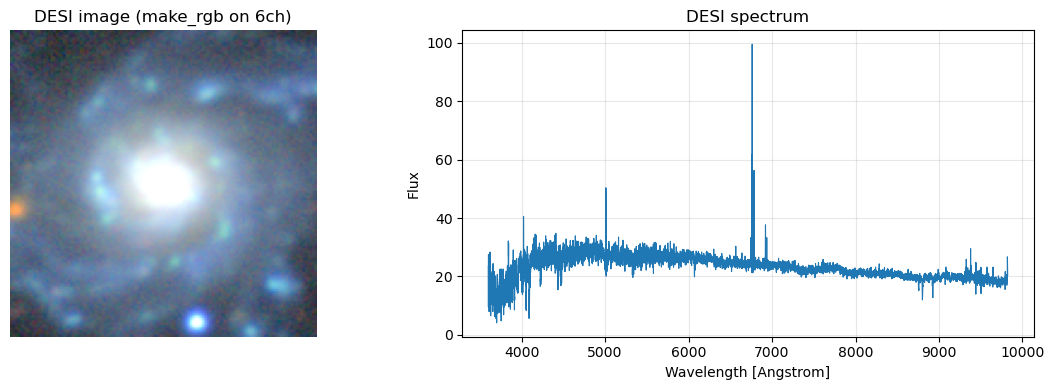

In [78]:
row_idx = 2  # Change this and re-run this cell.
# Operation 1: load one DESI sample into a one-sample loader
# This cell must be run after changing row_idx so downstream cells use new variables.

matches_csv = '/pscratch/sd/p/pzehao/desi_manga_matches.csv'
all_matches = pd.read_csv(matches_csv)

extractor = PairExtractor()
desi_tab = extractor.desi_table()

# Keep only cross-matches that exist in the loaded DESI table.
desi_targetids = set(desi_tab['TARGETID'].astype(np.int64).values)
matches_df = all_matches[all_matches['TARGETID'].isin(desi_targetids)].reset_index(drop=True)

if len(matches_df) == 0:
    raise RuntimeError('No eligible DESI-MaNGA pairs found in current DESI table')

# row_idx = 2  # Change this and re-run this cell.
if row_idx < 0 or row_idx >= len(matches_df):
    raise IndexError(f'row_idx={row_idx} out of range [0, {len(matches_df)-1}]')

match_row = matches_df.iloc[row_idx]
TARGETID_EXAMPLE = int(match_row['TARGETID'])

hit = desi_tab.loc[desi_tab['TARGETID'] == TARGETID_EXAMPLE]
if len(hit) == 0:
    raise KeyError(f'TARGETID={TARGETID_EXAMPLE} not found in DESI table after filtering')

DESI_INDEX = int(hit.index[0])
row = desi_tab.iloc[DESI_INDEX]

targetid = int(row['TARGETID'])
target_ra = float(row['TARGET_RA'])
target_dec = float(row['TARGET_DEC'])
fiber_ra = float(row['MEAN_FIBER_RA'])
fiber_dec = float(row['MEAN_FIBER_DEC'])
z = float(row['Z'])

loader = extractor.get_loader(DESI_INDEX)
batch = next(iter(loader))

spec_true = batch[0][0].detach().cpu().numpy()
img_6ch = batch[4][0].detach().cpu().numpy()
xy_pix = batch[8][0].detach().cpu().numpy()

plateifu, sep = extractor.match_manga(target_ra, target_dec)

print(f'Eligible pairs in current table: {len(matches_df)}')
print(f'Loaded row_idx={row_idx}, TARGETID={targetid}, DESI_INDEX={DESI_INDEX}')
print(f'MaNGA match: {plateifu} (sep={sep:.4f} arcsec)')
print(f'z={z:.5f}, image shape={img_6ch.shape}, spectrum shape={spec_true.shape}')

# Operation 2: visualize DESI image with your function + plot DESI spectrum
desi_rgb = make_rgb(img_6ch[[0, 1, 3]], 'ls_grz')
desi_wave = extractor.wave

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(desi_rgb)
ax[0].set_title('DESI image (make_rgb on 6ch)')
ax[0].axis('off')

ax[1].plot(desi_wave, spec_true, lw=0.8)
ax[1].set_title('DESI spectrum')
ax[1].set_xlabel('Wavelength [Angstrom]')
ax[1].set_ylabel('Flux')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
def visualize(model, spec: torch.Tensor, error: torch.Tensor, spec_pred: torch.Tensor, 
                error_pred: torch.Tensor, img: torch.Tensor, pred_img: torch.Tensor, error_img: torch.Tensor, mask_spec: torch.Tensor, mask_img: torch.Tensor, xy_pix: torch.Tensor,
                i: int = 0, nsmooth: int = 3):
    kernel = get_kernel(nsmooth)

    # Extract relevant sample
    target = spec[i].detach().cpu().numpy()
    target_error = error[i].detach().cpu().numpy()
    pred_mean = spec_pred[i].detach().cpu().numpy()
    pred_sigma = np.exp(error_pred[i].detach().cpu().numpy())
    patch_mask_spec = mask_spec[i].detach().cpu()
    patch_mask_img = mask_img[i].detach().cpu()

    # Smooth signal and error
    target_smooth = smooth_data(target, kernel)
    target_error_smooth = smooth_data(target_error, kernel)

    # Compute intervals
    pred_upper = pred_mean + pred_sigma
    pred_lower = pred_mean - pred_sigma
    data_upper = target_smooth + target_error_smooth
    data_lower = target_smooth - target_error_smooth

    # Plot masked reconstruction
    fig, ax = plt.subplots(figsize=(10, 3))
    offset = model.left_patches * model.patch_size
    x_range = np.arange(offset, offset + len(target_smooth))
    ax.plot(x_range, target_smooth, label="Target (smoothed)", color="orange", linewidth=1)
    ax.fill_between(x_range, data_lower, data_upper, color="orange", alpha=0.3, label="±σ data (smoothed)")
    ax.plot(pred_mean, label="Prediction", color="blue")
    ax.fill_between(range(len(pred_mean)), pred_lower, pred_upper, color="blue", alpha=0.3, label="±σ predicted")
    patch_len = model.patch_size
    for j, masked in enumerate(patch_mask_spec):
        if masked:
            start = offset + j * patch_len
            end = offset + (j + 1) * patch_len
            ax.axvspan(start, end, color='red', alpha=0.05)
    ax.set_title(f"Patch Size = {model.patch_size*model.chunk_size}, {model.mask_ratio} (Val Sample {i})")
    ax.set_xlabel("Pixel index")
    ax.set_ylabel("Value")
    ax.set_ylim(-0, 50)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    N = model.patch_embedimg.num_patches
    p = pred_img[i].view(model.num_img_channels, N, model.img_patch, model.img_patch)
    p = p.view(model.num_img_channels, 128//model.img_patch, 128//model.img_patch, model.img_patch, model.img_patch)                  # (C, 8, 8, 16, 16)
    pred_img_formatted = p.permute(0,1,3,2,4).reshape(model.num_img_channels, 128, 128).detach().cpu().numpy()
    
    img_formatted = img[i].detach().cpu().numpy() 
    pred_rgb = make_rgb(pred_img_formatted[[0, 1, 3]], "ls_grz") 
    img_rgb = make_rgb(img_formatted[[0, 1, 3]], "ls_grz") 
    
    # mask: (384,) -> (6,64) -> (6,8,8)
    # m = patch_mask_img.float().view(6, 64).view(6, 8, 8)

    # # opacity per spatial patch = fraction of channels masked
    # alpha_patch = m.mean(dim=0).cpu().numpy()                 # (8,8)
    # alpha128 = np.kron(alpha_patch, np.ones((16, 16)))        # (128,128)
    xy_pix_val = xy_pix[i].detach().cpu().numpy()

    fig2, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(img_rgb)
    axs[0].set_title("True")

    ticks = np.arange(0, 129, 16)
    axs[0].set_xticks(ticks)
    axs[0].set_yticks(ticks)

    axs[0].set_xticklabels(ticks - 64)
    axs[0].set_yticklabels(64 - ticks)

    axs[0].grid(True, color='white', alpha=0.7, linewidth=0.5)

    axs[0].scatter(
        xy_pix_val[0] + 64,
        64 - xy_pix_val[1],
        c='red', s=50, marker='x'
    )

    axs[1].imshow(pred_rgb)
    # axs[1].imshow(alpha128, cmap="Reds", alpha=alpha128)
    axs[1].set_title("Masked Reconstruction")
    axs[1].axis("off")

    plt.tight_layout()
    
    plt.show()
    plt.close(fig)
    plt.close(fig2)

In [80]:
device = next(model.parameters()).device
model.eval()

x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch

spec   = spec.to(device)
weig   = weig.to(device)
error  = error.to(device)
img    = img.to(device)
img_w  = img_w.to(device)
img_e  = img_e.to(device)
z      = z.to(device)
xy_pix = xy_pix.to(device)

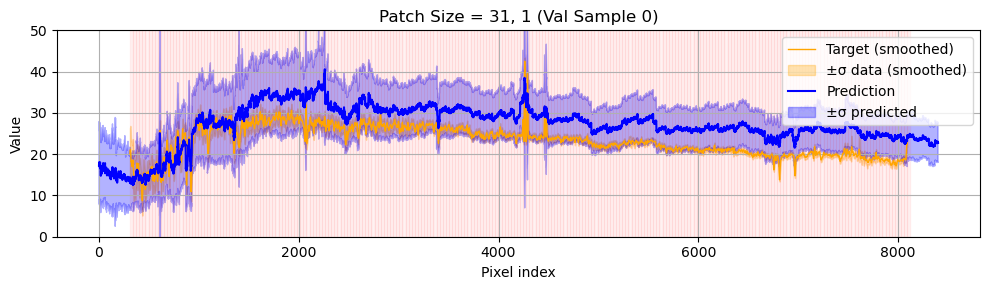

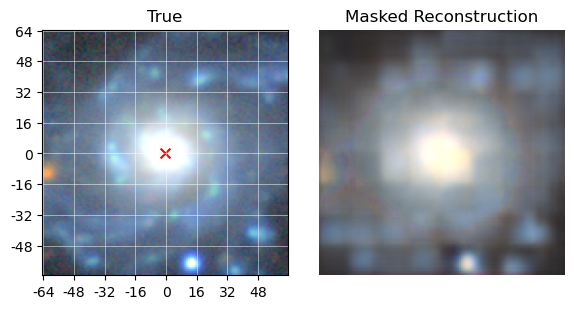

In [81]:
model.mask_ratio = 1
model.mask_ratio_img = 0
# z[0] = 0.2429
# xy_pix[0] = torch.tensor([48, -40])
spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)

token_mask = token_mask.unsqueeze(0).expand(spec.size(0), -1)
mask_spec = token_mask[:, :-model.num_patchesimg].long()
mask_img = token_mask[:, -model.num_patchesimg:].long()
visualize(model, spec, error, spec_pred, error_pred, img, pred_img, error_img, mask_spec, mask_img, xy_pix)

In [16]:
x.shape, spec.shape, weig.shape, error.shape, img.shape, img_w.shape, img_e.shape, z.shape, xy_pix.shape

(torch.Size([1, 7781]),
 torch.Size([1, 7781]),
 torch.Size([1, 7781]),
 torch.Size([1, 7781]),
 torch.Size([1, 6, 128, 128]),
 torch.Size([1, 6, 128, 128]),
 torch.Size([1, 6, 128, 128]),
 torch.Size([1]),
 torch.Size([1, 2]))

In [38]:
del spec_b, weig_b, error_b, img_b, img_w_b, img_e_b, z_b, xy_pix_chunk
del spec_pred, error_pred, pred_img, error_img, token_mask
torch.cuda.empty_cache()

In [ ]:
device = next(model.parameters()).device
model.eval()

x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch

# move inputs to GPU
spec   = spec.to(device)
weig   = weig.to(device)
error  = error.to(device)
img    = img.to(device)
img_w  = img_w.to(device)
img_e  = img_e.to(device)
z      = z.to(device)
xy_pix = xy_pix.to(device)

wave_obs = np.asarray(extractor.wave, dtype=np.float64)

# ---------------------------------------------------------
# choose finer sampling here
x_min, x_max, dx = -64, 64, 1
y_min, y_max, dy = -64, 64, 1
chunk_size = 128   # tune this: 32, 64, 128, ...
# ---------------------------------------------------------

# keep EXACT same ordering:
# outer loop: top -> bottom in y
# inner loop: left -> right in x
xs = torch.arange(x_min, x_max + 1, dx, device=device, dtype=xy_pix.dtype)
ys = torch.arange(y_max, y_min - 1, -dy, device=device, dtype=xy_pix.dtype)

nx = xs.numel()
ny = ys.numel()

coords = []
for i in range(ny):
    for j in range(nx):
        coords.append([xs[j], ys[i]])

coords = torch.stack(
    [torch.as_tensor(c, device=device, dtype=xy_pix.dtype) for c in coords],
    dim=0
)  # (N, 2)

N = coords.shape[0]

# outputs in flattened row-major order matching coords
halphas_flat       = np.zeros(N, dtype=np.float64)
nii6583_fluxs_flat = np.zeros(N, dtype=np.float64)
dv_kmses_flat      = np.zeros(N, dtype=np.float64)
dn4000s_flat       = np.zeros(N, dtype=np.float64)

with torch.no_grad():
    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)
        bsz = end - start

        xy_pix_chunk = coords[start:end]              # (bsz, 2)

        # repeat single example only for this chunk
        spec_b   = spec.repeat(bsz, 1)
        weig_b   = weig.repeat(bsz, 1)
        error_b  = error.repeat(bsz, 1)
        img_b    = img.repeat(bsz, 1, 1, 1)
        img_w_b  = img_w.repeat(bsz, 1, 1, 1)
        img_e_b  = img_e.repeat(bsz, 1, 1, 1)
        z_b      = z.repeat(bsz)

        spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(
            spec_b, weig_b, error_b, img_b, img_w_b, img_e_b, z_b, xy_pix_chunk
        )

        pred_np = spec_pred.detach().cpu().numpy()
        z_np    = z_b.detach().cpu().numpy()

        values_all = extract_halpha_kinematics(
            spectra=pred_np,
            wave_obs=wave_obs,
            redshifts=z_np,
            left_patches=model.left_patches,
            patch_size=model.patch_size,
            return_dataframe=False,
        )

        for k, values in enumerate(values_all):
            idx = start + k
            halphas_flat[idx]       = values['halpha_flux']
            nii6583_fluxs_flat[idx] = values['nii6583_flux']
            dv_kmses_flat[idx]      = values['dv_kms']
            dn4000s_flat[idx]       = values['dn4000']

# reshape back to grid with SAME ordering as original loop
halphas       = halphas_flat.reshape(ny, nx)
nii6583_fluxs = nii6583_fluxs_flat.reshape(ny, nx)
dv_kmses      = dv_kmses_flat.reshape(ny, nx)
dn4000s       = dn4000s_flat.reshape(ny, nx)

In [16]:
x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
wave_obs = np.asarray(extractor.wave, dtype=np.float64)
z_np = z.detach().cpu().numpy() if hasattr(z, 'detach') else np.asarray(z)
nii6583_fluxs = np.zeros((16,16))
halphas = np.zeros((16,16))
dv_kmses = np.zeros((16,16))
dn4000s = np.zeros((16,16))
n = 0
for i in range(0, 16): 
    for j in range(0, 16): 
        x, y = -60 + 8 * j, 60 - 8 * i
        xy_pix[0] = torch.tensor([x, y])
        print(n/256)
        spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)
        # visualize(model, spec, error, spec_pred, error_pred, img, pred_img, error_img, mask_spec, mask_img, xy_pix)
        pred_np = spec_pred.detach().cpu().numpy()
        values = extract_halpha_kinematics(spectra=pred_np, wave_obs=wave_obs, redshifts=z_np, left_patches=model.left_patches, patch_size=model.patch_size, return_dataframe=False)[0]
        halphas[i, j] = values['halpha_flux']
        # halphas[i, j] = np.sum(pred_np[0])
        nii6583_fluxs[i, j] = values['nii6583_flux']
        dv_kmses[i, j] = values['dv_kms']
        dn4000s[i, j] = values['dn4000']
        n += 1


inference: 256/4096


inference: 256/4096


KeyboardInterrupt: 

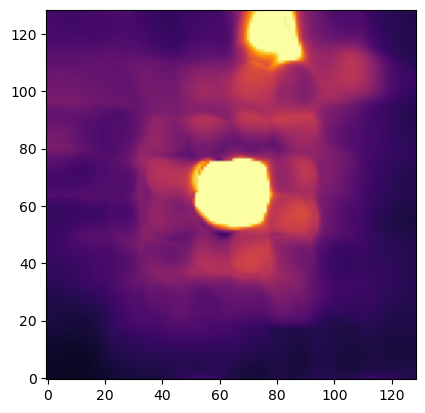

In [67]:
plt.imshow(halphas, cmap='inferno', vmin=0, vmax=20)
# flip plot vertically
plt.gca().invert_yaxis()
# plt.colorbar(label='H-alpha Flux')

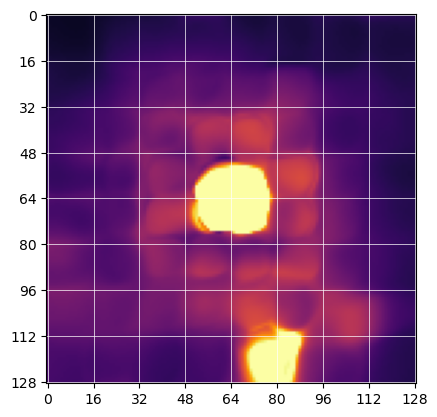

In [68]:
import numpy as np
import matplotlib.pyplot as plt

plt.imshow(halphas, cmap='inferno', vmin=0, vmax=20)

h, w = halphas.shape

# ticks every 16 pixels
plt.xticks(np.arange(0, w, 16))
plt.yticks(np.arange(0, h, 16))

# draw grid
plt.grid(color='white', linestyle='-', linewidth=0.5)

plt.show()

In [59]:
# crop to multiple of 4 first (since 129 not divisible by 4)
h, w = halphas.shape
h4, w4 = h // 4 * 4, w // 4 * 4
x = halphas[:h4, :w4]

# downscale by 4x4 averaging
down = x.reshape(h4//4, 4, w4//4, 4).mean(axis=(1, 3))

In [5]:
# Reusable DAP-like Halpha + kinematics extraction
# Fits local continuum + tied [NII]6548,6583 + Halpha with shared velocity/sigma.

from scipy.optimize import curve_fit

C_KMS = 299792.458
HA_REST = 6564.61
NII6548_REST = 6549.86
NII6583_REST = 6585.27
NII_RATIO_6583_TO_6548 = 3.06

# Dn4000 definition (rest frame)
DN4000_BLUE_MIN = 3850.0
DN4000_BLUE_MAX = 3950.0
DN4000_RED_MIN = 4000.0
DN4000_RED_MAX = 4100.0


def _gauss_from_flux(lam, flux_int, mu, sigma):
    amp = flux_int / (np.sqrt(2.0 * np.pi) * sigma)
    return amp * np.exp(-0.5 * ((lam - mu) / sigma) ** 2)


def _halpha_single_dap_like(wave_obs, flux_obs, z_obj, ivar_obs=None):
    wave_obs = np.asarray(wave_obs, dtype=np.float64)
    flux_obs = np.asarray(flux_obs, dtype=np.float64)

    if ivar_obs is not None:
        ivar_obs = np.asarray(ivar_obs, dtype=np.float64)

    lam0 = HA_REST * (1.0 + z_obj)
    win_half = 45.0 * (1.0 + z_obj)
    m = (
        np.isfinite(wave_obs)
        & np.isfinite(flux_obs)
        & (wave_obs >= lam0 - win_half)
        & (wave_obs <= lam0 + win_half)
    )
    if ivar_obs is not None:
        m &= np.isfinite(ivar_obs) & (ivar_obs > 0)

    w = wave_obs[m]
    f = flux_obs[m]
    if len(w) < 30:
        raise RuntimeError('Not enough valid pixels in Halpha window for fitting')

    side = ((w < lam0 - 12.0) | (w > lam0 + 12.0))
    c0 = float(np.nanmedian(f[side])) if np.any(side) else float(np.nanmedian(f))
    c1 = 0.0

    cont_guess = c0 + c1 * (w - lam0)
    pos = np.clip(f - cont_guess, 0.0, None)
    f_ha0 = max(float(np.trapz(pos, w)), 1e-3)
    f_nii6583_0 = 0.3 * f_ha0

    def model(lam, cont0, cont1, f_ha, f_nii6583, dv_kms, sigma_kms):
        z_shift = (1.0 + z_obj) * (1.0 + dv_kms / C_KMS)
        mu_ha = HA_REST * z_shift
        mu_6548 = NII6548_REST * z_shift
        mu_6583 = NII6583_REST * z_shift

        sigma_ha = (sigma_kms / C_KMS) * mu_ha
        sigma_6548 = (sigma_kms / C_KMS) * mu_6548
        sigma_6583 = (sigma_kms / C_KMS) * mu_6583

        f_nii6548 = f_nii6583 / NII_RATIO_6583_TO_6548

        y = cont0 + cont1 * (lam - lam0)
        y += _gauss_from_flux(lam, f_ha, mu_ha, sigma_ha)
        y += _gauss_from_flux(lam, f_nii6548, mu_6548, sigma_6548)
        y += _gauss_from_flux(lam, f_nii6583, mu_6583, sigma_6583)
        return y

    p0 = [c0, c1, f_ha0, f_nii6583_0, 0.0, 120.0]
    lower = [-np.inf, -np.inf, 0.0, 0.0, -400.0, 20.0]
    upper = [np.inf, np.inf, np.inf, np.inf, 400.0, 500.0]

    sigma_y = None
    if ivar_obs is not None:
        sigma_y = 1.0 / np.sqrt(np.clip(ivar_obs[m], 1e-20, None))

    popt, _ = curve_fit(
        model,
        w,
        f,
        p0=p0,
        bounds=(lower, upper),
        sigma=sigma_y,
        absolute_sigma=(sigma_y is not None),
        maxfev=20000,
    )

    cont0, cont1, f_ha, f_nii6583, dv_kms, sigma_kms = popt
    yfit = model(w, *popt)
    rms = float(np.sqrt(np.nanmean((f - yfit) ** 2)))

    # Compute Dn4000 on full spectrum
    blue_min_obs = DN4000_BLUE_MIN * (1.0 + z_obj)
    blue_max_obs = DN4000_BLUE_MAX * (1.0 + z_obj)
    red_min_obs = DN4000_RED_MIN * (1.0 + z_obj)
    red_max_obs = DN4000_RED_MAX * (1.0 + z_obj)
    
    m_blue = (wave_obs >= blue_min_obs) & (wave_obs <= blue_max_obs) & np.isfinite(flux_obs)
    m_red = (wave_obs >= red_min_obs) & (wave_obs <= red_max_obs) & np.isfinite(flux_obs)
    
    if np.any(m_blue) and np.any(m_red):
        flux_blue = np.mean(flux_obs[m_blue])
        flux_red = np.mean(flux_obs[m_red])
        dn4000 = float(flux_red / flux_blue) if flux_blue > 0 else np.nan
    else:
        dn4000 = np.nan

    return {
        'halpha_flux': float(f_ha),
        'nii6583_flux': float(f_nii6583),
        'dv_kms': float(dv_kms),
        'sigma_kms': float(sigma_kms),
        'fit_rms': rms,
        'dn4000': dn4000,
        'window_wave': w,
        'window_flux': f,
        'window_fit': yfit,
    }


def extract_halpha_kinematics(spectra, wave_obs, redshifts, ivar=None, left_patches=None, patch_size=None, return_dataframe=True):
    """
    Compute DAP-like Halpha intensity and kinematics from one or many spectra.

    Returns:
    - Single spectrum input: dict with scalar outputs + diagnostics
    - Batch input: DataFrame (default) or list[dict]
    """
    wave_obs = np.asarray(wave_obs, dtype=np.float64)
    L = len(wave_obs)

    spec_arr = np.asarray(spectra)
    is_single_input = (spec_arr.ndim == 1)
    if is_single_input:
        spec_arr = spec_arr[None, :]

    N = spec_arr.shape[0]

    z_arr = np.asarray(redshifts, dtype=np.float64)
    if z_arr.ndim == 0:
        z_arr = np.full(N, float(z_arr), dtype=np.float64)
    if len(z_arr) != N:
        raise ValueError(f'redshifts length {len(z_arr)} does not match number of spectra {N}')

    ivar_arr = None
    if ivar is not None:
        ivar_arr = np.asarray(ivar)
        if ivar_arr.ndim == 1:
            ivar_arr = ivar_arr[None, :]
        if ivar_arr.shape[0] != N:
            raise ValueError('ivar batch size does not match spectra batch size')

    def _extract_center(x):
        if x.shape[-1] == L:
            return x
        if left_patches is None or patch_size is None:
            raise ValueError('Spectrum length differs from wave grid; provide left_patches and patch_size for center extraction')
        offset = int(left_patches) * int(patch_size)
        y = x[..., offset:offset + L]
        if y.shape[-1] != L:
            raise ValueError(f'Cannot extract center region of length {L} from spectrum length {x.shape[-1]}')
        return y

    spec_arr = _extract_center(spec_arr)
    if ivar_arr is not None:
        ivar_arr = _extract_center(ivar_arr)

    rows = []
    diag = []
    for i in range(N):
        iv_i = None if ivar_arr is None else ivar_arr[i]
        fit = _halpha_single_dap_like(wave_obs, spec_arr[i], z_arr[i], iv_i)
        rows.append({
            'index': i,
            'halpha_flux': fit['halpha_flux'],
            'nii6583_flux': fit['nii6583_flux'],
            'dv_kms': fit['dv_kms'],
            'sigma_kms': fit['sigma_kms'],
            'fit_rms': fit['fit_rms'],
            'dn4000': fit['dn4000'],
        })
        diag.append(fit)

    if is_single_input:
        out = rows[0]
        out['diagnostics'] = diag[0]
        return out

    if return_dataframe:
        return pd.DataFrame(rows)
    return rows


# Example: run on model predictions (single or batch)
pred_np = spec_pred.detach().cpu().numpy()
wave_obs = np.asarray(extractor.wave, dtype=np.float64)
z_np = z.detach().cpu().numpy() if hasattr(z, 'detach') else np.asarray(z)

res = extract_halpha_kinematics(
    spectra=pred_np,
    wave_obs=wave_obs,
    redshifts=z_np,
    left_patches=model.left_patches,
    patch_size=model.patch_size,
    return_dataframe=True,
)

if isinstance(res, pd.DataFrame):
    print(res[['index', 'halpha_flux', 'dv_kms', 'sigma_kms', 'dn4000', 'fit_rms']].head())
    single = extract_halpha_kinematics(
        spectra=pred_np[0],
        wave_obs=wave_obs,
        redshifts=float(np.asarray(z_np).reshape(-1)[0]),
        left_patches=model.left_patches,
        patch_size=model.patch_size,
        return_dataframe=False,
    )
else:
    print({k: res[k] for k in ['halpha_flux', 'dv_kms', 'sigma_kms', 'dn4000', 'fit_rms']})
    single = res

d = single['diagnostics']
plt.figure(figsize=(8, 3.5))
plt.plot(d['window_wave'], d['window_flux'], lw=1.0, label='spec_pred window')
plt.plot(d['window_wave'], d['window_fit'], lw=1.5, label='DAP-like fit')
plt.xlabel('Wavelength [Angstrom]')
plt.ylabel('Flux')
plt.title(f"Halpha fit, flux={single['halpha_flux']:.4g}, dv={single['dv_kms']:.1f} km/s, dn4000={single['dn4000']:.3f}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'spec_pred' is not defined

MaNGA match: 8616-9102 (sep=0.006 arcsec)


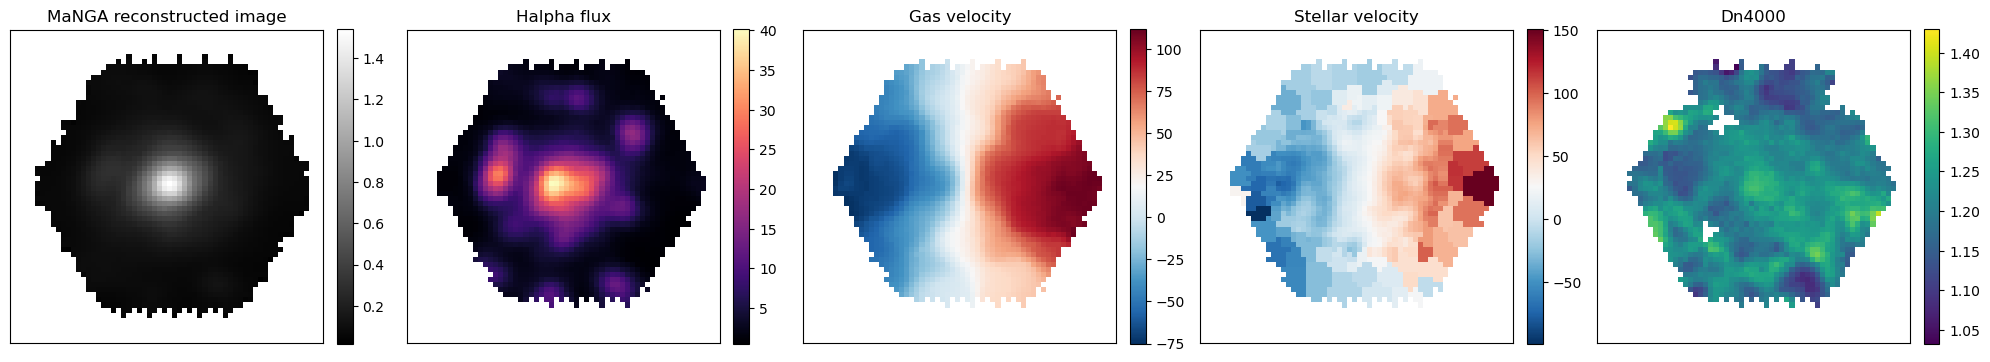

In [73]:
# Operation 3: fetch corresponding MaNGA object and visualize maps
plateifu, match_sep_arcsec = extractor.match_manga(target_ra, target_dec)
if match_sep_arcsec > 1.0:
    raise RuntimeError(f'Nearest MaNGA object too far: {match_sep_arcsec:.3f} arcsec')

maps = extractor.get_maps(plateifu)
print(f'MaNGA match: {plateifu} (sep={match_sep_arcsec:.3f} arcsec)')

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
titles = [
    ('manga_image', 'MaNGA reconstructed image', 'gray'),
    ('ha_flux', 'Halpha flux', 'magma'),
    ('gas_velocity', 'Gas velocity', 'RdBu_r'),
    ('stellar_velocity', 'Stellar velocity', 'RdBu_r'),
    ('dn4000', 'Dn4000', 'viridis'),
]

for i, (k, t, c) in enumerate(titles):
    im = ax[i].imshow(maps[k], origin='lower', cmap=c)
    ax[i].set_title(t)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    plt.colorbar(im, ax=ax[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [85]:
fiber_ra, fiber_dec = 322, -0.01

In [86]:
# Operation 4: extract MaNGA cube spectrum at chosen location, mark location on SDSS image, show spectrum
manga_spec = extractor.spectrum_from_cube(plateifu, fiber_ra, fiber_dec)
sdss_img = extractor.get_sdss_image(target_ra, target_dec, width=300, height=300, scale=0.262)
x_sdss, y_sdss = extractor.sky_to_cutout_pixel(
    ra=fiber_ra, dec=fiber_dec,
    ra0=target_ra, dec0=target_dec,
    width=300, height=300, scale_arcsec=0.262,
 )

# concise consistency check against DESI spectrum
wmin = max(np.nanmin(desi_wave), np.nanmin(manga_spec['wave']))
wmax = min(np.nanmax(desi_wave), np.nanmax(manga_spec['wave']))
m_d = (desi_wave >= wmin) & (desi_wave <= wmax) & np.isfinite(spec_true)
m_m = (manga_spec['wave'] >= wmin) & (manga_spec['wave'] <= wmax) & np.isfinite(manga_spec['flux'])
manga_on_desi = np.interp(desi_wave[m_d], manga_spec['wave'][m_m], manga_spec['flux'][m_m])
desi_norm = spec_true[m_d] / np.nanmedian(spec_true[m_d])
manga_norm = manga_on_desi / np.nanmedian(manga_on_desi)
v = np.isfinite(desi_norm) & np.isfinite(manga_norm)
corr = float(np.corrcoef(desi_norm[v], manga_norm[v])[0, 1])

print(f"cube spaxel=(ix,iy)=({manga_spec['ix']},{manga_spec['iy']}), sky->spaxel sep={manga_spec['sep_arcsec']:.3f} arcsec")
print(f'DESI vs MaNGA spectral shape corr: {corr:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(sdss_img)
ax[0].scatter([x_sdss], [y_sdss], s=90, marker='x', c='red', linewidths=2, label='Spectrum location')
ax[0].set_title('SDSS image + marked extraction location')
ax[0].legend(loc='lower right', fontsize=8)
ax[0].axis('off')

ax[1].plot(desi_wave[m_d], desi_norm, lw=1.0, label='DESI (normalized)')
ax[1].plot(desi_wave[m_d], manga_norm, lw=1.0, label='MaNGA cube @ marked location')
ax[1].set_title(f'Spectrum check (corr={corr:.3f})')
ax[1].set_xlabel('Wavelength [Angstrom]')
ax[1].set_ylabel('Normalized flux')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

a string value was expected. [astropy.wcs.wcs]


IndexError: index 5427 is out of bounds for axis 2 with size 62